In [1]:
# ==========================================
# SMARTVISION AI - EDA
# STEP 7.1: IMPORTS
# ==========================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# ==========================================
# STEP 7.2: DATASET PATH
# ==========================================

BASE_DIR = r"D:\Smartvision_project\smartvision_dataset"

classification_dir = os.path.join(BASE_DIR, "classification")
detection_dir = os.path.join(BASE_DIR, "detection")

print("📁 Dataset:", BASE_DIR)
print("📂 Classification:", os.path.exists(classification_dir))
print("📂 Detection:", os.path.exists(detection_dir))
print("📄 Metadata:", os.path.exists(os.path.join(BASE_DIR, "dataset_metadata.json")))

📁 Dataset: D:\Smartvision_project\smartvision_dataset
📂 Classification: True
📂 Detection: True
📄 Metadata: True


In [3]:
# ==========================================
# STEP 7.3: CLASS DISTRIBUTION
# ==========================================

classes = sorted(os.listdir(
    os.path.join(classification_dir, "train")
))

train_counts = []
val_counts = []
test_counts = []

for class_name in classes:
    train_path = os.path.join(classification_dir, "train", class_name)
    val_path = os.path.join(classification_dir, "val", class_name)
    test_path = os.path.join(classification_dir, "test", class_name)

    train_counts.append(len(os.listdir(train_path)))
    val_counts.append(len(os.listdir(val_path)))
    test_counts.append(len(os.listdir(test_path)))

# Create DataFrame
class_distribution = pd.DataFrame({
    "Class": classes,
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
})

class_distribution["Total"] = (
    class_distribution["Train"] +
    class_distribution["Validation"] +
    class_distribution["Test"]
)

print("=" * 70)
print("📊 CLASS DISTRIBUTION")
print("=" * 70)

display(class_distribution)

print("\nTotal images:")
print(f"Train      : {class_distribution['Train'].sum()}")
print(f"Validation : {class_distribution['Validation'].sum()}")
print(f"Test       : {class_distribution['Test'].sum()}")
print(f"Total      : {class_distribution['Total'].sum()}")

📊 CLASS DISTRIBUTION


,Class,Train,Validation,Test,Total
0,airplane,70,15,15,100
1,bed,70,15,15,100
2,bench,70,15,15,100
3,bicycle,70,15,15,100
4,bird,70,15,15,100
5,bottle,70,15,15,100
6,bowl,70,15,15,100
7,bus,70,15,15,100
8,cake,70,15,15,100
9,car,70,15,15,100



Total images:
Train      : 1750
Validation : 375
Test       : 375
Total      : 2500


In [4]:
# ==========================================
# STEP 7.4: IMAGE DIMENSIONS & FORMAT
# ==========================================

print("=" * 70)
print("🖼️ IMAGE DIMENSIONS & FORMAT ANALYSIS")
print("=" * 70)

image_info = []

# Check images from all splits
for split in ["train", "val", "test"]:
    
    split_path = os.path.join(classification_dir, split)

    for class_name in os.listdir(split_path):
        
        class_path = os.path.join(split_path, class_name)

        for filename in os.listdir(class_path):
            
            file_path = os.path.join(class_path, filename)

            try:
                with Image.open(file_path) as img:
                    image_info.append({
                        "split": split,
                        "class": class_name,
                        "filename": filename,
                        "width": img.width,
                        "height": img.height,
                        "mode": img.mode,
                        "format": img.format
                    })

            except Exception as e:
                print(f"⚠️ Could not read {file_path}: {e}")

image_df = pd.DataFrame(image_info)

print(f"\n📊 Images checked: {len(image_df)}")

print("\n📐 Image dimensions:")
print(image_df[["width", "height"]].value_counts())

print("\n🎨 Image color mode:")
print(image_df["mode"].value_counts())

print("\n📁 Image format:")
print(image_df["format"].value_counts())

🖼️ IMAGE DIMENSIONS & FORMAT ANALYSIS

📊 Images checked: 2500

📐 Image dimensions:
width  height
224    224       2500
Name: count, dtype: int64

🎨 Image color mode:
mode
RGB    2486
L        14
Name: count, dtype: int64

📁 Image format:
format
JPEG    2500
Name: count, dtype: int64


In [5]:
# ==========================================
# STEP 7.5: FIND NON-RGB IMAGES
# ==========================================

non_rgb = image_df[image_df["mode"] != "RGB"]

print("=" * 70)
print("⚠️ NON-RGB IMAGE CHECK")
print("=" * 70)

print(f"\nNon-RGB images: {len(non_rgb)}")

display(non_rgb[["split", "class", "filename", "width", "height", "mode", "format"]])

⚠️ NON-RGB IMAGE CHECK

Non-RGB images: 14


,split,class,filename,width,height,mode,format
20,train,airplane,airplane_train_0020.jpg,224,224,L,JPEG
693,train,car,car_train_0063.jpg,224,224,L,JPEG
694,train,car,car_train_0064.jpg,224,224,L,JPEG
695,train,car,car_train_0065.jpg,224,224,L,JPEG
696,train,car,car_train_0066.jpg,224,224,L,JPEG
697,train,car,car_train_0067.jpg,224,224,L,JPEG
1262,train,motorcycle,motorcycle_train_0002.jpg,224,224,L,JPEG
1351,train,person,person_train_0021.jpg,224,224,L,JPEG
1783,val,bench,bench_val_0003.jpg,224,224,L,JPEG
1784,val,bench,bench_val_0004.jpg,224,224,L,JPEG


In [6]:
print("\n📊 NON-RGB IMAGES BY CLASS")
print("=" * 50)

non_rgb_class_counts = non_rgb["class"].value_counts()

print(non_rgb_class_counts)


📊 NON-RGB IMAGES BY CLASS
class
car           5
bench         3
truck         2
airplane      1
motorcycle    1
person        1
bowl          1
Name: count, dtype: int64


🖼️ SAMPLE IMAGES FROM ALL 25 CLASSES


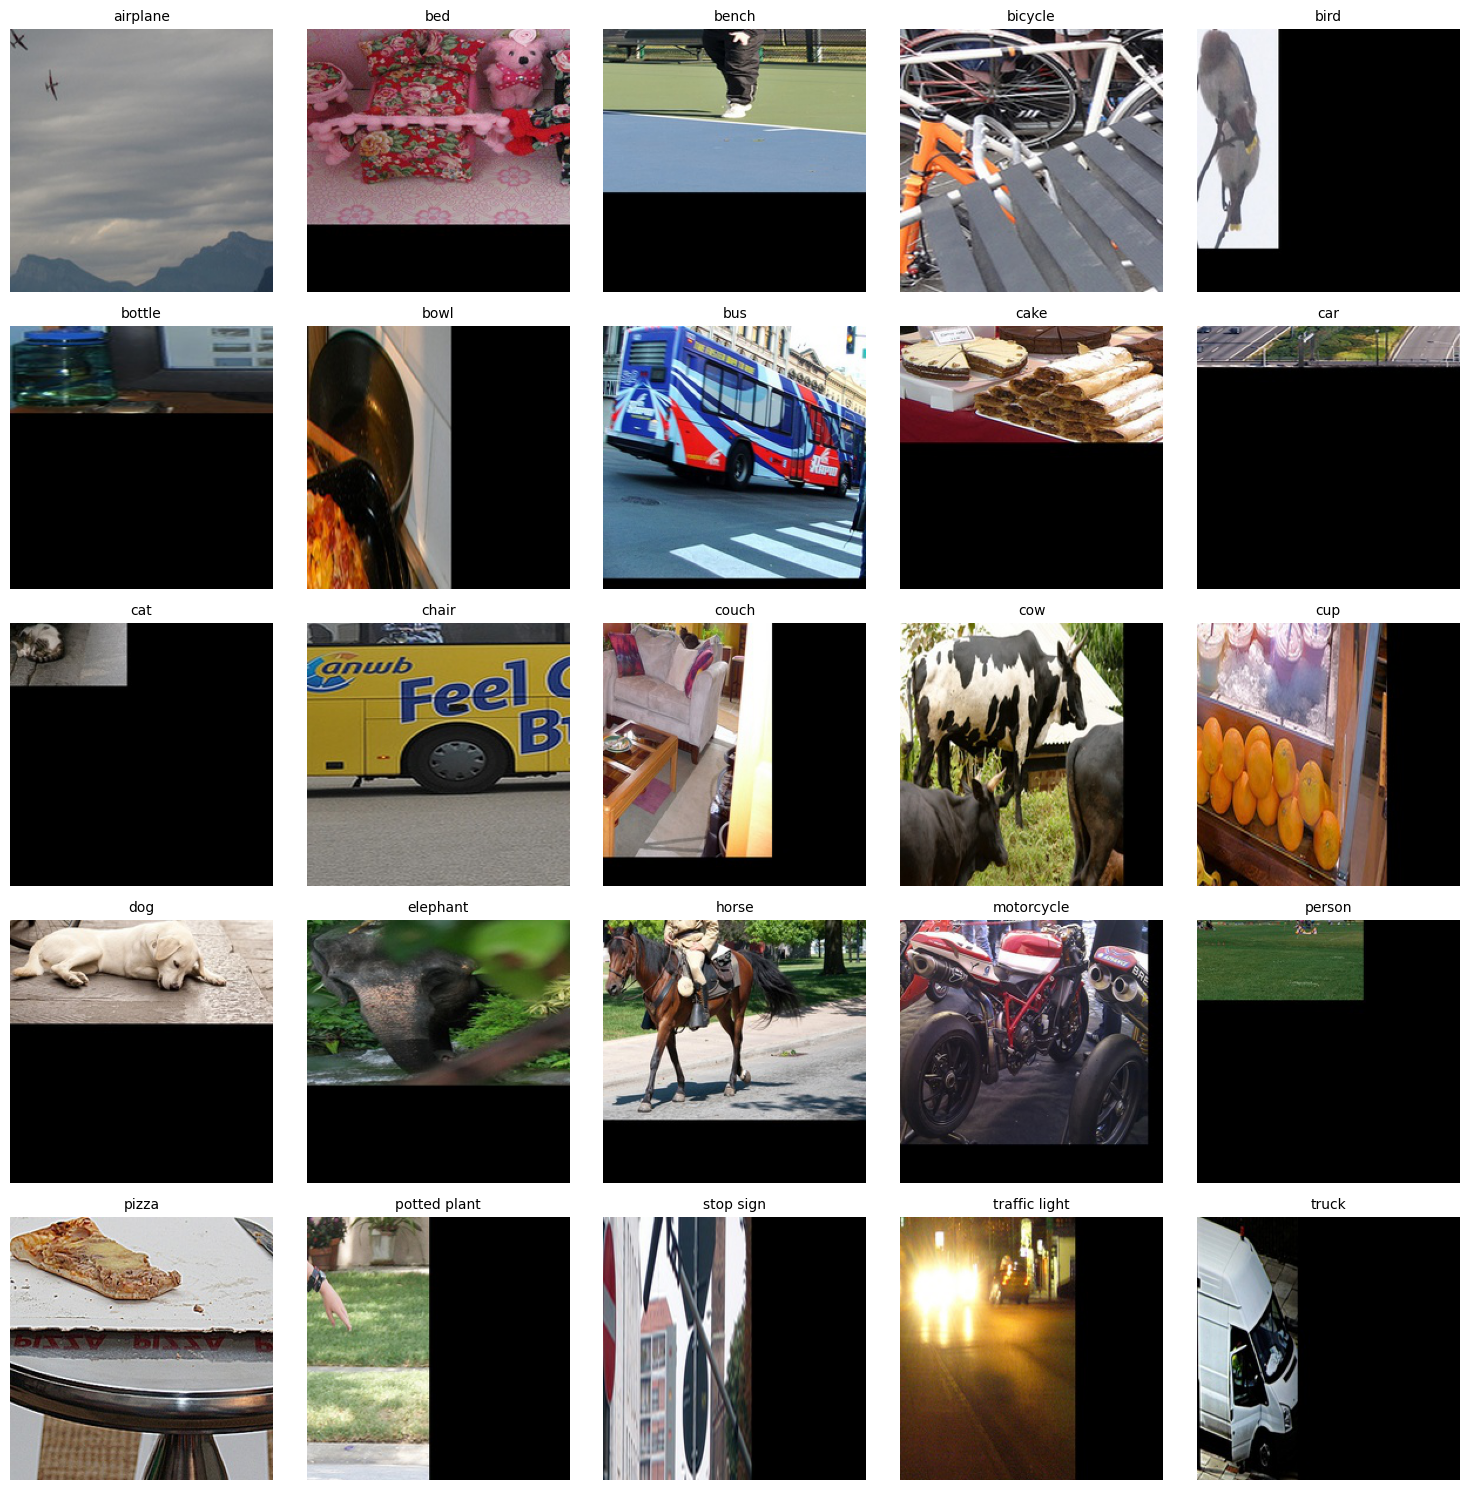

In [7]:
# ==========================================
# STEP 7.6: SAMPLE IMAGE VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import random
import os

BASE_DIR = r"D:\Smartvision_project\smartvision_dataset"

classes = sorted(os.listdir(os.path.join(BASE_DIR, "classification", "train")))

print("=" * 70)
print("🖼️ SAMPLE IMAGES FROM ALL 25 CLASSES")
print("=" * 70)

fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for ax, class_name in zip(axes.ravel(), classes):

    class_path = os.path.join(
        BASE_DIR,
        "classification",
        "train",
        class_name
    )

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Select one random image
    image_file = random.choice(images)
    image_path = os.path.join(class_path, image_file)

    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(class_name, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# ==========================================
# STEP 7.7: CLASS DISTRIBUTION CHECK
# ==========================================

import os
import matplotlib.pyplot as plt

BASE_DIR = r"D:\Smartvision_project\smartvision_dataset"

TRAIN_DIR = os.path.join(
    BASE_DIR,
    "classification",
    "train"
)

# Get all class folders
classes = sorted([
    folder for folder in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, folder))
])

# Count images in each class
class_counts = {}

for class_name in classes:

    class_path = os.path.join(TRAIN_DIR, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    class_counts[class_name] = len(images)


# Print results
print("=" * 70)
print("📊 CLASS DISTRIBUTION")
print("=" * 70)

for class_name, count in class_counts.items():
    print(f"{class_name:<20} : {count}")

print("=" * 70)

print("Total classes:", len(classes))
print("Total training images:", sum(class_counts.values()))

print("Minimum images in a class:", min(class_counts.values()))
print("Maximum images in a class:", max(class_counts.values()))

📊 CLASS DISTRIBUTION
airplane             : 70
bed                  : 70
bench                : 70
bicycle              : 70
bird                 : 70
bottle               : 70
bowl                 : 70
bus                  : 70
cake                 : 70
car                  : 70
cat                  : 70
chair                : 70
couch                : 70
cow                  : 70
cup                  : 70
dog                  : 70
elephant             : 70
horse                : 70
motorcycle           : 70
person               : 70
pizza                : 70
potted plant         : 70
stop sign            : 70
traffic light        : 70
truck                : 70
Total classes: 25
Total training images: 1750
Minimum images in a class: 70
Maximum images in a class: 70


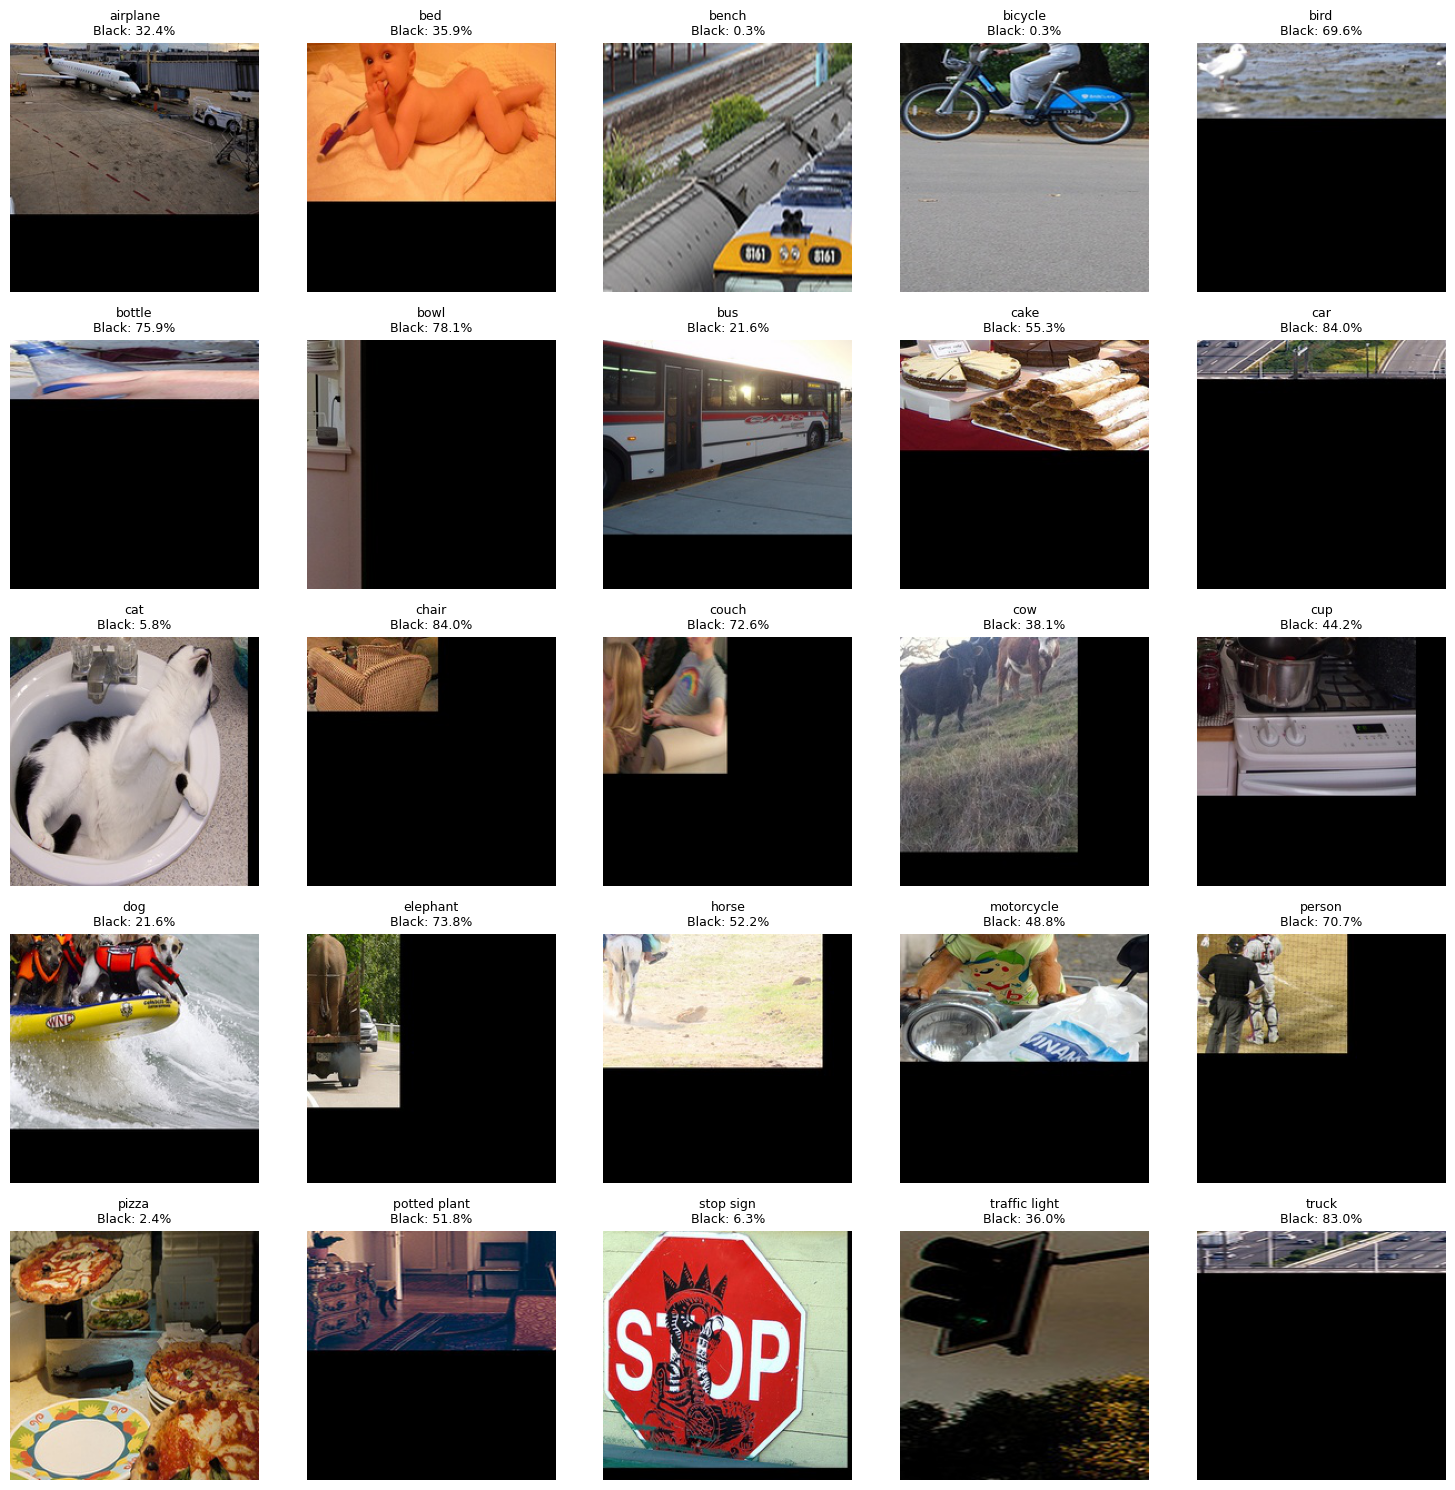

In [9]:
# ==========================================
# STEP 7.7.1: CHECK BLACK PIXELS
# ==========================================

from PIL import Image
import numpy as np
import os
import random
import matplotlib.pyplot as plt

BASE_DIR = r"D:\Smartvision_project\smartvision_dataset"

TRAIN_DIR = os.path.join(
    BASE_DIR,
    "classification",
    "train"
)

classes = sorted([
    folder for folder in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, folder))
])

# Pick one image from each class
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for ax, class_name in zip(axes.ravel(), classes):

    class_path = os.path.join(TRAIN_DIR, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_file = random.choice(images)
    image_path = os.path.join(class_path, image_file)

    img = Image.open(image_path).convert("RGB")
    arr = np.array(img)

    # Count almost-black pixels
    black_pixels = np.all(arr < 10, axis=2)

    black_percentage = (
        black_pixels.sum() / black_pixels.size
    ) * 100

    ax.imshow(img)
    ax.set_title(
        f"{class_name}\nBlack: {black_percentage:.1f}%",
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Image: bed_train_0000.jpg
Size: (224, 224)


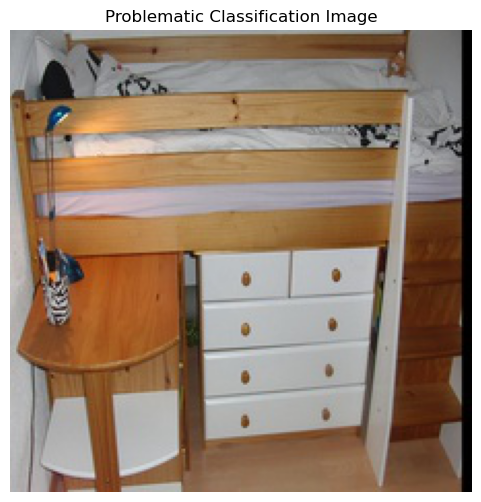

In [10]:
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = r"D:\Smartvision_project\smartvision_dataset"

image_path = os.path.join(
    BASE_DIR,
    "classification",
    "train",
    "bed"
)

image_file = os.listdir(image_path)[0]

full_path = os.path.join(image_path, image_file)

img = Image.open(full_path).convert("RGB")

print("Image:", image_file)
print("Size:", img.size)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Problematic Classification Image")
plt.axis("off")
plt.show()

In [11]:
arr = np.array(img)

black_pixels = np.all(arr < 10, axis=2)

percentage = (black_pixels.sum() / black_pixels.size) * 100

print(f"Black pixel percentage: {percentage:.2f}%")

Black pixel percentage: 1.81%


In [12]:
# ==========================================
# STEP 7.7.2: CHECK BLACK PIXELS IN ALL IMAGES
# ==========================================

from PIL import Image
import numpy as np
import os

BASE_DIR = r"D:\Smartvision_project\smartvision_dataset"

TRAIN_DIR = os.path.join(
    BASE_DIR,
    "classification",
    "train"
)

results = []

for class_name in sorted(os.listdir(TRAIN_DIR)):

    class_path = os.path.join(TRAIN_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    for image_file in os.listdir(class_path):

        if not image_file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        image_path = os.path.join(class_path, image_file)

        try:
            img = Image.open(image_path).convert("RGB")
            arr = np.array(img)

            black_pixels = np.all(arr < 10, axis=2)

            black_percentage = (
                black_pixels.sum() / black_pixels.size
            ) * 100

            results.append({
                "class": class_name,
                "image": image_file,
                "black_percentage": black_percentage
            })

        except Exception as e:
            print("Error:", image_path, e)

print("Total images checked:", len(results))

Total images checked: 1750


In [13]:
black_values = [
    item["black_percentage"]
    for item in results
]

print("\nBlack Pixel Statistics")
print("=" * 50)

print(f"Minimum : {min(black_values):.2f}%")
print(f"Average : {np.mean(black_values):.2f}%")
print(f"Median  : {np.median(black_values):.2f}%")
print(f"Maximum : {max(black_values):.2f}%")


Black Pixel Statistics
Minimum : 0.00%
Average : 38.64%
Median  : 35.04%
Maximum : 98.66%


In [18]:
from PIL import Image
import os
import pandas as pd

dataset_path = r"D:\Smartvision_project\smartvision_dataset"

widths = []
heights = []
failed_images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            filepath = os.path.join(root, file)

            try:
                with Image.open(filepath) as img:
                    widths.append(img.width)
                    heights.append(img.height)
            except:
                failed_images.append(filepath)

print("=" * 70)
print("📐 IMAGE DIMENSION ANALYSIS")
print("=" * 70)

print("Total images checked:", len(widths))
print("Failed/corrupt images:", len(failed_images))

print("\nWidth:")
print("Minimum:", min(widths))
print("Maximum:", max(widths))
print("Average:", round(sum(widths) / len(widths), 2))

print("\nHeight:")
print("Minimum:", min(heights))
print("Maximum:", max(heights))
print("Average:", round(sum(heights) / len(heights), 2))

📐 IMAGE DIMENSION ANALYSIS
Total images checked: 5831
Failed/corrupt images: 0

Width:
Minimum: 224
Maximum: 640
Average: 436.97

Height:
Minimum: 133
Maximum: 640
Average: 366.35


📏 ASPECT RATIO ANALYSIS
Minimum : 0.56
Average : 1.18
Median  : 1.0
Maximum : 4.81


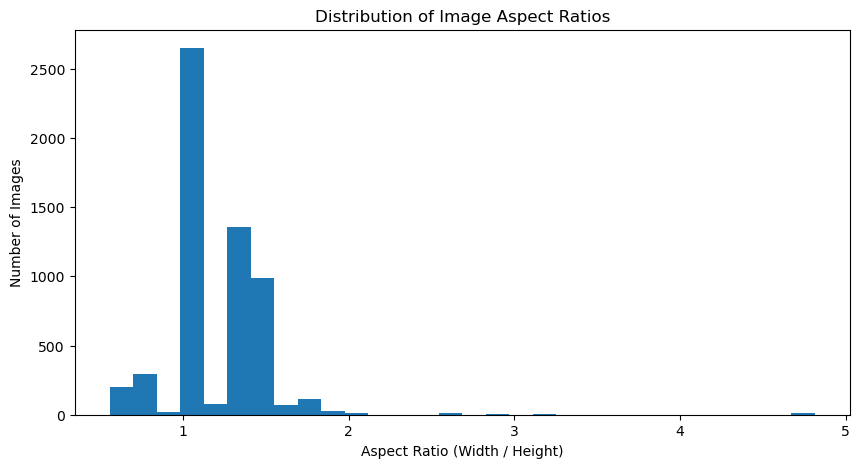

In [19]:
import matplotlib.pyplot as plt

aspect_ratios = [w / h for w, h in zip(widths, heights)]

print("=" * 70)
print("📏 ASPECT RATIO ANALYSIS")
print("=" * 70)

print("Minimum :", round(min(aspect_ratios), 2))
print("Average :", round(sum(aspect_ratios) / len(aspect_ratios), 2))
print("Median  :", round(sorted(aspect_ratios)[len(aspect_ratios)//2], 2))
print("Maximum :", round(max(aspect_ratios), 2))

plt.figure(figsize=(10, 5))
plt.hist(aspect_ratios, bins=30)
plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Aspect Ratios")
plt.show()

In [20]:
import os

dataset_path = r"D:\Smartvision_project\smartvision_dataset"

print("=" * 70)
print("📄 JSON / ANNOTATION FILES")
print("=" * 70)

json_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(".json"):
            filepath = os.path.join(root, file)
            json_files.append(filepath)

print("Total JSON files found:", len(json_files))

for filepath in json_files:
    print(filepath)

📄 JSON / ANNOTATION FILES
Total JSON files found: 1
D:\Smartvision_project\smartvision_dataset\dataset_metadata.json


In [21]:
import json
import pandas as pd
import matplotlib.pyplot as plt

metadata_path = r"D:\Smartvision_project\smartvision_dataset\dataset_metadata.json"

with open(metadata_path, "r") as f:
    metadata = json.load(f)

print("=" * 70)
print("📊 METADATA STRUCTURE")
print("=" * 70)

print("Metadata type:", type(metadata))

if isinstance(metadata, dict):
    print("Top-level keys:")
    for key in metadata.keys():
        print(" -", key)

elif isinstance(metadata, list):
    print("Number of records:", len(metadata))
    if len(metadata) > 0:
        print("First record:")
        print(metadata[0])

📊 METADATA STRUCTURE
Metadata type: <class 'dict'>
Top-level keys:
 - total_images
 - classes
 - splits
 - classification
 - detection
 - dataset_path


In [22]:
import os

detection_path = r"D:\Smartvision_project\smartvision_dataset\detection"

print("=" * 70)
print("🎯 DETECTION DATASET STRUCTURE")
print("=" * 70)

if os.path.exists(detection_path):
    for root, dirs, files in os.walk(detection_path):
        level = root.replace(detection_path, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}📁 {os.path.basename(root)}/")

        for file in files[:10]:
            print(f"{indent}  📄 {file}")

        if level >= 2:
            dirs[:] = []
else:
    print("❌ Detection folder not found")

🎯 DETECTION DATASET STRUCTURE
📁 detection/
  📄 data.yaml
  📁 images/
    📄 image_000000.jpg
    📄 image_000001.jpg
    📄 image_000002.jpg
    📄 image_000003.jpg
    📄 image_000004.jpg
    📄 image_000005.jpg
    📄 image_000006.jpg
    📄 image_000007.jpg
    📄 image_000008.jpg
    📄 image_000009.jpg
  📁 labels/
    📄 image_000000.txt
    📄 image_000001.txt
    📄 image_000002.txt
    📄 image_000003.txt
    📄 image_000004.txt
    📄 image_000005.txt
    📄 image_000006.txt
    📄 image_000007.txt
    📄 image_000008.txt
    📄 image_000009.txt
  📁 train/
    📁 images/
      📄 image_000000.jpg
      📄 image_000001.jpg
      📄 image_000012.jpg
      📄 image_000014.jpg
      📄 image_000018.jpg
      📄 image_000019.jpg
      📄 image_000022.jpg
      📄 image_000023.jpg
      📄 image_000025.jpg
      📄 image_000026.jpg
  📁 val/
    📁 images/
      📄 image_000002.jpg
      📄 image_000005.jpg
      📄 image_000007.jpg
      📄 image_000010.jpg
      📄 image_000027.jpg
      📄 image_000046.jpg
      📄 ima

In [23]:
import os
import matplotlib.pyplot as plt

labels_path = r"D:\Smartvision_project\smartvision_dataset\detection\labels"

objects_per_image = []
empty_images = []

for filename in os.listdir(labels_path):

    if filename.endswith(".txt"):

        filepath = os.path.join(labels_path, filename)

        with open(filepath, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        count = len(lines)
        objects_per_image.append(count)

        if count == 0:
            empty_images.append(filename)

print("=" * 70)
print("📊 OBJECTS PER IMAGE ANALYSIS")
print("=" * 70)

print("Total images analyzed:", len(objects_per_image))
print("Images with no objects:", len(empty_images))

print("\nMinimum objects per image:", min(objects_per_image))
print("Maximum objects per image:", max(objects_per_image))

average_objects = sum(objects_per_image) / len(objects_per_image)

print("Average objects per image:", round(average_objects, 2))

sorted_objects = sorted(objects_per_image)

median_objects = sorted_objects[len(sorted_objects) // 2]

print("Median objects per image:", median_objects)

print("\nObject count distribution:")

for count in sorted(set(objects_per_image)):
    print(f"{count} object(s): {objects_per_image.count(count)} images")

📊 OBJECTS PER IMAGE ANALYSIS
Total images analyzed: 2125
Images with no objects: 0

Minimum objects per image: 1
Maximum objects per image: 47
Average objects per image: 10.15
Median objects per image: 7

Object count distribution:
1 object(s): 179 images
2 object(s): 214 images
3 object(s): 194 images
4 object(s): 166 images
5 object(s): 139 images
6 object(s): 98 images
7 object(s): 102 images
8 object(s): 89 images
9 object(s): 63 images
10 object(s): 81 images
11 object(s): 48 images
12 object(s): 72 images
13 object(s): 104 images
14 object(s): 34 images
15 object(s): 45 images
16 object(s): 63 images
17 object(s): 74 images
18 object(s): 15 images
19 object(s): 55 images
20 object(s): 6 images
21 object(s): 43 images
22 object(s): 1 images
23 object(s): 38 images
24 object(s): 11 images
26 object(s): 11 images
27 object(s): 38 images
28 object(s): 28 images
29 object(s): 6 images
30 object(s): 44 images
31 object(s): 31 images
33 object(s): 2 images
37 object(s): 9 images
43 obje

In [25]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 1.8 MB/s eta 0:00:25
    --------------------------------------- 1.0/44.0 MB 2.3 MB/s eta 0:00:19
   - -------------------------------------- 1.6/44.0 MB 2.4 MB/s eta 0:00:18
   -- ------------------------------------- 2.4/44.0 MB 2.7 MB/s eta 0:00:16
   -- ------------------------------------- 3.1/44.0 MB 2.8 MB/s eta 0:00:15
   --- ------------------------------------ 3.7/44.0 MB 3.0 MB/s eta 0:00:14
   ---- ----------------------------------- 4.7/44.0 MB 3.2 MB/s eta 0:00:13
   ----- ---------------------------------- 5.8/44.0 MB 3.4 MB/s eta 0:00:12
   ----- ---------------------------------- 6.6/44.0 MB 3.4 MB/s eta 0:00:11
   ------ --------------------------------- 7.1/44.0 MB 3.5 MB/s eta 0:00:11
   ------- -------------------------------- 8.4/44.0 MB 3.6 MB/s eta 0:00:10
   -------- -

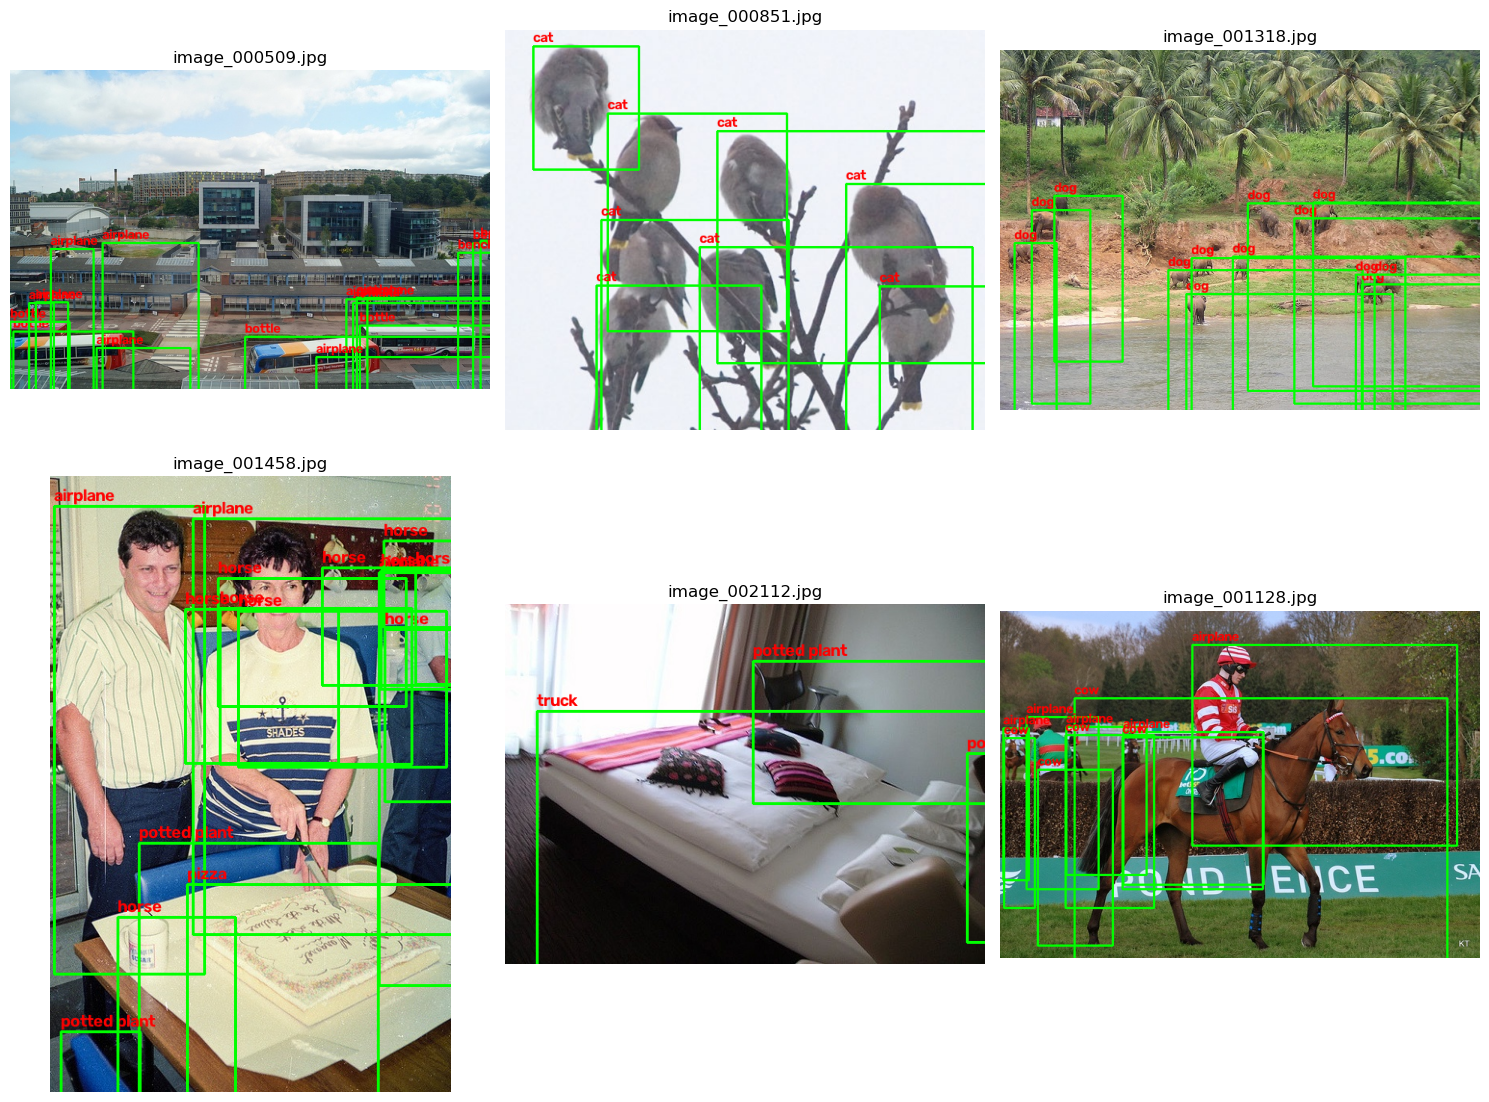

In [1]:
import os
import random
import cv2
import matplotlib.pyplot as plt

images_path = r"D:\Smartvision_project\smartvision_dataset\detection\images"
labels_path = r"D:\Smartvision_project\smartvision_dataset\detection\labels"

# Class names
class_names = [
    "airplane",
    "bed",
    "bench",
    "bicycle",
    "bird",
    "bottle",
    "bowl",
    "bus",
    "cake",
    "car",
    "cat",
    "chair",
    "couch",
    "cow",
    "cup",
    "dog",
    "elephant",
    "horse",
    "motorcycle",
    "person",
    "pizza",
    "potted plant",
    "stop sign",
    "traffic light",
    "truck"
]

# Get images that have corresponding labels
image_files = [
    f for f in os.listdir(images_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
    and os.path.exists(
        os.path.join(
            labels_path,
            os.path.splitext(f)[0] + ".txt"
        )
    )
]

# Select 6 random images
selected_images = random.sample(image_files, min(6, len(image_files)))

plt.figure(figsize=(15, 12))

for i, image_file in enumerate(selected_images):

    image_path = os.path.join(images_path, image_file)
    label_file = os.path.join(
        labels_path,
        os.path.splitext(image_file)[0] + ".txt"
    )

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    height, width, _ = image.shape

    with open(label_file, "r") as f:
        annotations = f.readlines()

    for annotation in annotations:

        values = annotation.strip().split()

        if len(values) != 5:
            continue

        class_id = int(values[0])
        x_center = float(values[1])
        y_center = float(values[2])
        box_width = float(values[3])
        box_height = float(values[4])

        # Convert YOLO normalized coordinates to pixels
        x_center *= width
        y_center *= height
        box_width *= width
        box_height *= height

        x1 = int(x_center - box_width / 2)
        y1 = int(y_center - box_height / 2)
        x2 = int(x_center + box_width / 2)
        y2 = int(y_center + box_height / 2)

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        label = class_names[class_id]

        cv2.putText(
            image,
            label,
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_file)

plt.tight_layout()
plt.show()

In [2]:
import os
from collections import Counter

labels_path = r"D:\Smartvision_project\smartvision_dataset\detection\labels"

class_names = [
    "airplane",
    "bed",
    "bench",
    "bicycle",
    "bird",
    "bottle",
    "bowl",
    "bus",
    "cake",
    "car",
    "cat",
    "chair",
    "couch",
    "cow",
    "cup",
    "dog",
    "elephant",
    "horse",
    "motorcycle",
    "person",
    "pizza",
    "potted plant",
    "stop sign",
    "traffic light",
    "truck"
]

class_counts = Counter()

for filename in os.listdir(labels_path):

    if filename.endswith(".txt"):

        filepath = os.path.join(labels_path, filename)

        with open(filepath, "r") as f:
            for line in f:

                values = line.strip().split()

                if len(values) == 5:
                    class_id = int(values[0])
                    class_counts[class_id] += 1

print("=" * 70)
print("🎯 YOLO CLASS DISTRIBUTION")
print("=" * 70)

for class_id in range(25):

    count = class_counts[class_id]
    print(f"{class_id:2d} - {class_names[class_id]:20s}: {count}")

print("\nTotal annotated objects:", sum(class_counts.values()))
print("Classes present:", len(class_counts))
print("Expected classes:", len(class_names))

missing = [
    class_names[i]
    for i in range(25)
    if class_counts[i] == 0
]

if missing:
    print("\n⚠️ Missing classes:")
    print(missing)
else:
    print("\n✅ All 25 classes are present!")

🎯 YOLO CLASS DISTRIBUTION
 0 - airplane            : 6314
 1 - bed                 : 653
 2 - bench               : 2147
 3 - bicycle             : 484
 4 - bird                : 301
 5 - bottle              : 513
 6 - bowl                : 566
 7 - bus                 : 877
 8 - cake                : 104
 9 - car                 : 347
10 - cat                 : 862
11 - chair               : 162
12 - couch               : 359
13 - cow                 : 400
14 - cup                 : 374
15 - dog                 : 435
16 - elephant            : 1242
17 - horse               : 1265
18 - motorcycle          : 633
19 - person              : 276
20 - pizza               : 828
21 - potted plant        : 1532
22 - stop sign           : 265
23 - traffic light       : 516
24 - truck               : 123

Total annotated objects: 21578
Classes present: 25
Expected classes: 25

✅ All 25 classes are present!


In [3]:
import os

classification_path = r"D:\Smartvision_project\smartvision_dataset\classification"

print("=" * 70)
print("📂 CLASSIFICATION DATASET")
print("=" * 70)

for root, dirs, files in os.walk(classification_path):

    level = root.replace(classification_path, "").count(os.sep)

    if level <= 2:
        indent = "    " * level
        print(f"{indent}📁 {os.path.basename(root)}/")

        for file in files[:5]:
            print(f"{indent}    📄 {file}")

📂 CLASSIFICATION DATASET
📁 classification/
    📁 test/
        📁 airplane/
            📄 airplane_test_0000.jpg
            📄 airplane_test_0001.jpg
            📄 airplane_test_0002.jpg
            📄 airplane_test_0003.jpg
            📄 airplane_test_0004.jpg
        📁 bed/
            📄 bed_test_0000.jpg
            📄 bed_test_0001.jpg
            📄 bed_test_0002.jpg
            📄 bed_test_0003.jpg
            📄 bed_test_0004.jpg
        📁 bench/
            📄 bench_test_0000.jpg
            📄 bench_test_0001.jpg
            📄 bench_test_0002.jpg
            📄 bench_test_0003.jpg
            📄 bench_test_0004.jpg
        📁 bicycle/
            📄 bicycle_test_0000.jpg
            📄 bicycle_test_0001.jpg
            📄 bicycle_test_0002.jpg
            📄 bicycle_test_0003.jpg
            📄 bicycle_test_0004.jpg
        📁 bird/
            📄 bird_test_0000.jpg
            📄 bird_test_0001.jpg
            📄 bird_test_0002.jpg
            📄 bird_test_0003.jpg
            📄 bird_test_0004.jp

In [4]:
import os

classification_path = r"D:\Smartvision_project\smartvision_dataset\classification"

splits = ["train", "val", "test"]

print("=" * 70)
print("📊 CLASSIFICATION DATASET SPLIT SUMMARY")
print("=" * 70)

for split in splits:

    split_path = os.path.join(classification_path, split)

    print(f"\n📁 {split.upper()}")

    total = 0

    for class_name in sorted(os.listdir(split_path)):

        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):

            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

            total += count

            print(f"{class_name:20s}: {count}")

    print("-" * 40)
    print(f"Total {split} images: {total}")

print("\n" + "=" * 70)
print("✅ CLASSIFICATION DATASET CHECK COMPLETE")
print("=" * 70)

📊 CLASSIFICATION DATASET SPLIT SUMMARY

📁 TRAIN
airplane            : 70
bed                 : 70
bench               : 70
bicycle             : 70
bird                : 70
bottle              : 70
bowl                : 70
bus                 : 70
cake                : 70
car                 : 70
cat                 : 70
chair               : 70
couch               : 70
cow                 : 70
cup                 : 70
dog                 : 70
elephant            : 70
horse               : 70
motorcycle          : 70
person              : 70
pizza               : 70
potted plant        : 70
stop sign           : 70
traffic light       : 70
truck               : 70
----------------------------------------
Total train images: 1750

📁 VAL
airplane            : 15
bed                 : 15
bench               : 15
bicycle             : 15
bird                : 15
bottle              : 15
bowl                : 15
bus                 : 15
cake                : 15
car                 : 15
cat 